# Step 4 — Figure (Panels a/b/c)

Reproduce the whole-brain functional architecture figure.

Run `01_load_first_level_data.ipynb` and `02_glm_and_contrasts.ipynb` first.

In [1]:
# Load configuration and upstream artifacts required by the Figure code below.
import importlib.util
import os
import os.path as op
import subprocess
import sys
from glob import glob
from pathlib import Path

import nibabel as nib
import pandas as pd
import yaml
from IPython.display import display
from joblib import Memory
from nilearn.glm import threshold_stats_img
from nilearn.image import math_img, new_img_like

if importlib.util.find_spec("atlasreader") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "atlasreader"])

for _base in (Path.cwd(), *Path.cwd().parents[:6]):
    for _candidate in (_base, _base / "brain_activation"):
        if (_candidate / "config.yaml").is_file():
            ROOT = _candidate.resolve()
            break
    else:
        continue
    break
else:
    raise FileNotFoundError(
        "Could not find brain_activation/config.yaml. "
        "Open the brain_activation project in Jupyter."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from nilearn_compat import NiftiMasker, get_statmap_info, process_img

PROJECT = ROOT.parent
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
artifacts_dir = RESULTS / "artifacts"
res_path = RESULTS / "second_level"
cache_dir = RESULTS / "cachedir"
cache_dir.mkdir(parents=True, exist_ok=True)

def resolve_config_path(path_str):
    p = Path(path_str)
    return p.resolve() if p.is_absolute() else (ROOT / p).resolve()

cfg = yaml.safe_load((ROOT / "config.yaml").read_text(encoding="utf-8"))
nii_str = cfg["analysis"]["nii_str"]
first_level_path = resolve_config_path(cfg["paths"]["first_level_derivatives"]) / nii_str

nii_files = []
for subdir in sorted(str(p) for p in first_level_path.glob("sub-*/patterns")):
    sub_nii_files = glob(op.join(subdir, "*-*_beta.nii.gz"))
    if len(sub_nii_files) > 1:
        sub_niis = [f for f in sub_nii_files if "error_trial" not in f]
    else:
        sub_niis = sub_nii_files
    nii_files.extend(sub_niis)

memory = Memory(location=str(cache_dir), verbose=0)

df = pd.read_csv(artifacts_dir / "design_df.csv")

contrast_root = Path(res_path) / nii_str
contrast_dirs = sorted(contrast_root.glob("*_contrast"))
if not contrast_dirs:
    raise FileNotFoundError(
        f"No contrast outputs found under {contrast_root}. "
        "Run 02_glm_and_contrasts.ipynb first."
    )
simple_contrasts = {d.name.replace("_contrast", ""): None for d in contrast_dirs}

simple_results = []
for name in simple_contrasts.keys():
    z_path = contrast_root / f"{name}_contrast" / f"{name}_unthresholded.nii"
    if not z_path.exists():
        raise FileNotFoundError(
            f"Missing z-map: {z_path}. Run 02_glm_and_contrasts.ipynb first."
        )
    simple_results.append({"z_map": nib.load(str(z_path))})

print("Figure inputs ready:")
print(f"  contrasts: {len(simple_contrasts)}")
print(f"  subjects: {df['subject'].nunique()}")


D:\文件同步\文件\数据分析结果\data_code_figure\brain_activation\nilearn_compat.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: F401


The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data

Figure inputs ready:
  contrasts: 8
  subjects: 3


Example mode: cluster_extent=1, alpha=0.05


C:\Users\lei\AppData\Local\Temp\ipykernel_40708\2285896225.py:72: UserWarning: The given float value must not exceed 3.408206232814435. But, you have given threshold=4.373857080753245.
  _, thr = threshold_stats_img(z_map, alpha=alpha, height_control='bonferroni', cluster_threshold=cluster_extent)
C:\Users\lei\AppData\Local\Temp\ipykernel_40708\2285896225.py:72: UserWarning: The given float value must not exceed 3.6685421297234724. But, you have given threshold=4.373857080753245.
  _, thr = threshold_stats_img(z_map, alpha=alpha, height_control='bonferroni', cluster_threshold=cluster_extent)


Interaction cluster direction: pos (contrast: Long-Short_x_diff-same, peak MNI: (np.float64(14.0), np.float64(36.0), np.float64(30.0)))


C:\Users\lei\AppData\Local\Temp\ipykernel_40708\2285896225.py:231: RuntimeWarning: [NiftiMasker.fit] Generation of a mask has been requested (imgs != None) while a mask was given at masker creation. Given mask will be used.
  masker.fit(roi_mask)
C:\Users\lei\AppData\Local\Temp\ipykernel_40708\2285896225.py:234: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  beta_vals = masker.transform(fp).ravel()


[plot_img_on_surf] Dataset directory found: C:\Users\lei\nilearn_data\fsaverage

...

D:\ProgramData\Paper2Any\venv\Lib\site-packages\nilearn\surface\surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


[plot_img_on_surf] Dataset directory found: C:\Users\lei\nilearn_data\fsaverage

D:\ProgramData\Paper2Any\venv\Lib\site-packages\nilearn\surface\surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


D:\ProgramData\Paper2Any\venv\Lib\site-packages\nilearn\surface\surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


Saved Figure to D:\文件同步\文件\数据分析结果\data_code_figure\brain_activation\figures\Figure_whole_brain_architecture.[png|pdf|eps|svg]


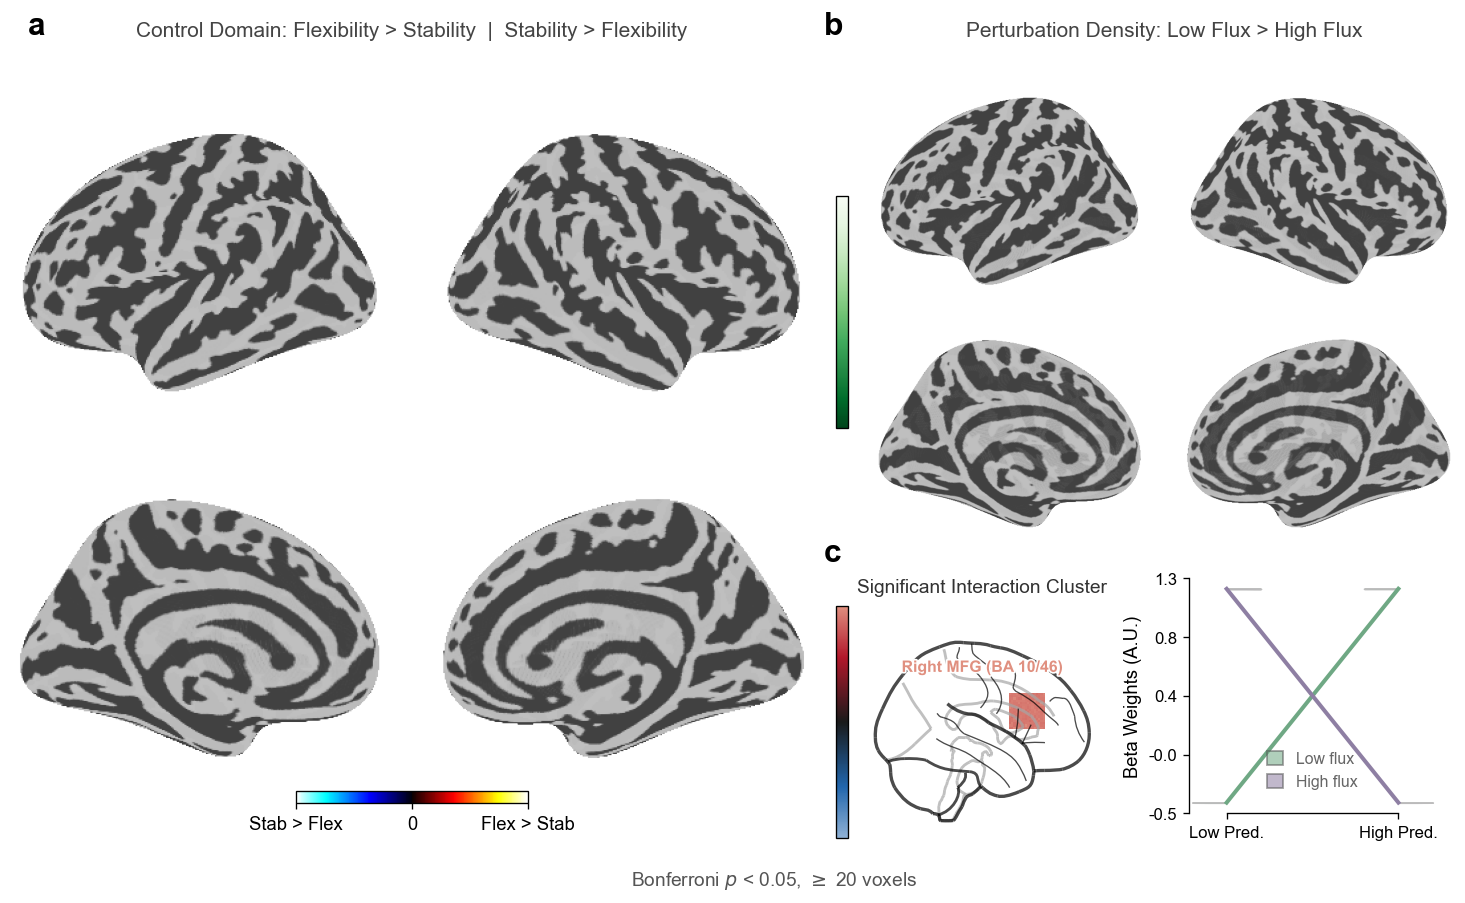

,long_short,probability,mean,sem,density,predictability
0,Long,diff,1.200499,0.000335,Low Density,High Pred.
1,Long,same,-0.399846,0.000272,Low Density,Low Pred.
2,Short,diff,-0.399747,0.000265,High Density,High Pred.
3,Short,same,1.199817,0.000409,High Density,Low Pred.


In [2]:
from io import BytesIO
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from PIL import Image
from nilearn.datasets import fetch_surf_fsaverage
from nilearn.plotting import plot_img_on_surf, plot_glass_brain, cm as nl_cm
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 12, 'axes.linewidth': 0.8, 'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10, 'figure.dpi': 120, 'savefig.dpi': 600, 'axes.spines.top': False, 'axes.spines.right': False})
_stats = cfg.get('statistics', {})
_example = cfg.get('pipeline', {}).get('example_mode', False)
CLUSTER_EXTENT = int(_stats.get('cluster_extent_voxels', 20))
ALPHA = float(_stats.get('alpha', 0.05))
if _example:
    print(f'Example mode: cluster_extent={CLUSTER_EXTENT}, alpha={ALPHA}')
INTERACTION_CONTRAST = 'Long-Short_x_diff-same'
SURF_VIEWS = ['lateral', 'medial']
SURF_HEMIS = ['left', 'right']
SURF_CORTEX_ALPHA = 0.22
SURF_MESH = 'fsaverage'
SURF_DPI_BASE = 150
PANEL_B_RENDER_SCALE = 1.65
PANEL_B_AXES_SCALE = 0.9
SURF_ROW_GAP_SCALE = 0.8
PANEL_A_ROW_GAP_SCALE = SURF_ROW_GAP_SCALE * 0.9
PANEL_B_ROW_GAP_SCALE = SURF_ROW_GAP_SCALE * 0.7
PANEL_C_CONTENT_DY = 0.058
PANEL_C_GLASS_UP = -0.012
PANEL_C_AXES_SCALE = 0.64
PANEL_C_DY = 0.028
PANEL_C_LINE_DX = -0.054
PANEL_C_BLOCK_DX = -0.014
PANEL_C_GLASS_DX = -0.043
PANEL_C_CONTENT_DX = -0.012
PANEL_C_LINE_HEIGHT_SCALE = 0.8
PANEL_AB_TOP_Y = 0.905
A_LABEL_DX = 0.02
PANEL_B_CONTENT_DX = -0.012
FIG_SAVE_DPI = 600
CBAR_LEN_FRAC = 0.14
CBAR_THICK_FRAC = 0.012
PANEL_A_DY = 0.012
PANEL_A_CBAR_DY = -0.019
FIG_FOOTER_Y = 0.061
PANEL_C_LABEL_DY = -0.026
PANEL_C_LABEL_ONLY_UP = 0.032
PANEL_LABEL_FS = 19
INTERACTION_CMAP = LinearSegmentedColormap.from_list('interaction_div', [(0.0, '#8eb0d4'), (0.22, '#2166ac'), (0.5, '#1a1a1a'), (0.78, '#b2182b'), (1.0, '#e09080')], N=256)
GLASS_BRAIN_MODE = 'x'
DENSITY_LABELS = {'Long': 'Low Density', 'Short': 'High Density'}
PRED_LABELS = {'same': 'Low Pred.', 'diff': 'High Pred.'}
PRED_ORDER = ['same', 'diff']
DENSITY_ORDER = ['Long', 'Short']
DENSITY_COLORS = {'Long': '#6FA884', 'Short': '#8E7FA3'}
VIOLIN_WIDTH = 0.2
VIOLIN_EDGE_COLOR = '#565656'
VIOLIN_EDGE_LW = 1.1
DENSITY_LEGEND_LABELS = {'Long': 'Low Density', 'Short': 'High Density'}

def _get_z_map(contrast_name, results=None, contrasts=None):
    results = simple_results if results is None else results
    contrasts = simple_contrasts if contrasts is None else contrasts
    keys = list(contrasts.keys())
    if contrast_name not in keys:
        raise KeyError(f"Contrast '{contrast_name}' not found. Available: {keys}")
    return results[keys.index(contrast_name)]['z_map']

def _bonferroni_thresh(z_map, cluster_extent=CLUSTER_EXTENT, alpha=ALPHA):
    _, thr = threshold_stats_img(z_map, alpha=alpha, height_control='bonferroni', cluster_threshold=cluster_extent)
    return float(thr)

def _cluster_mask(z_map, threshold):
    clust_img = process_img(z_map, voxel_thresh=threshold, cluster_extent=CLUSTER_EXTENT)
    return _ensure_3d(math_img('img != 0', img=clust_img))

def _interaction_cluster(z_map, threshold):
    """Match upstream plot_results(): detect clusters on pos or neg side."""
    pos_stat = math_img('img * (img > 0)', img=z_map)
    pos_clust = process_img(pos_stat, voxel_thresh=threshold, cluster_extent=CLUSTER_EXTENT)
    if np.any(pos_clust.get_fdata()):
        direction = 'pos'
        display_stat = pos_stat
        cluster_img = pos_clust
    else:
        neg_stat = math_img('-1 * (img * (img < 0))', img=z_map)
        cluster_img = process_img(neg_stat, voxel_thresh=threshold, cluster_extent=CLUSTER_EXTENT)
        if not np.any(cluster_img.get_fdata()):
            raise RuntimeError(f"No significant interaction cluster for '{INTERACTION_CONTRAST}' at Bonferroni z >= {threshold:.2f} (cluster >= {CLUSTER_EXTENT}).")
        direction = 'neg'
        display_stat = neg_stat
    inter_mask = _ensure_3d(math_img('img != 0', img=cluster_img))
    clust_frame, _ = get_statmap_info(display_stat, cluster_extent=CLUSTER_EXTENT, voxel_thresh=threshold)
    if clust_frame.empty:
        data = cluster_img.get_fdata()
        labels = np.unique(data[data != 0])
        if labels.size == 0:
            raise RuntimeError('Interaction cluster labels are empty after thresholding.')
        label = labels[np.argmax([np.sum(data == lab) for lab in labels])]
        stat_data = display_stat.get_fdata()
        masked = np.where(data == label, stat_data, -np.inf)
        idx = np.unravel_index(np.argmax(masked), stat_data.shape)
        peak_xyz = tuple(nib.affines.apply_affine(cluster_img.affine, idx)[:3])
    else:
        peak = clust_frame.iloc[0]
        peak_xyz = (peak['peak_x'], peak['peak_y'], peak['peak_z'])
    signed_display = _ensure_3d(math_img('img1 * img2', img1=_ensure_3d(z_map), img2=inter_mask))
    return (signed_display, inter_mask, display_stat, peak_xyz, direction)

def _ensure_3d(img):
    """Collapse atlasreader cluster maps (4D) to 3D for nilearn surf plotting."""
    data = np.asarray(img.get_fdata(), dtype=float)
    while data.ndim > 3:
        data = np.sum(data, axis=-1)
    return new_img_like(img, data)

def _threshold_stat_img(stat_img, threshold, two_sided=True):
    data = stat_img.get_fdata().copy()
    if two_sided:
        data = np.where(np.abs(data) >= threshold, data, 0)
    else:
        data = np.where(data >= threshold, data, 0)
    return new_img_like(stat_img, data)

def _stat_vmax(stat_img):
    return float(np.nanmax(np.abs(stat_img.get_fdata()))) or 1.0
_FSAVERAGE = None

def _get_fsaverage():
    global _FSAVERAGE
    if _FSAVERAGE is None:
        _FSAVERAGE = fetch_surf_fsaverage()
    return _FSAVERAGE

def _content_mask(img, white_thresh=248):
    """Non-background mask for RGB/RGBA montage images."""
    img = np.asarray(img)
    if img.ndim == 3 and img.shape[2] == 4:
        return img[..., 3] > 12
    if img.ndim == 2:
        return img < white_thresh
    return np.any(img[..., :3] < white_thresh, axis=2)

def _trim_image_whitespace(img_rgb, white_thresh=248, pad=6):
    """Crop outer margins so surface montage fills axes without zoom-crop."""
    img = np.asarray(img_rgb)
    mask = _content_mask(img, white_thresh=white_thresh)
    if not np.any(mask):
        return img
    ys, xs = np.where(mask)
    y0, y1 = (max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad + 1))
    x0, x1 = (max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad + 1))
    return img[y0:y1, x0:x1]

def _crop_image_left(img, pad=6, white_thresh=248):
    """Crop excess blank margin on the left of a figure/montage image."""
    img = np.asarray(img)
    mask = _content_mask(img, white_thresh=white_thresh)
    if not np.any(mask):
        return img
    ys, xs = np.where(mask)
    x0 = max(0, int(xs.min()) - pad)
    return img[:, x0:]

def _compress_surf_row_gap(img_rgb, gap_scale=SURF_ROW_GAP_SCALE):
    """Shrink vertical gutter between lateral/medial surface rows."""
    img = np.asarray(img_rgb)
    h = img.shape[0]
    cy = h // 2
    band = max(8, int(h * 0.12))
    y0, y1 = (max(0, cy - band), min(h, cy + band))
    remove = int((y1 - y0) * (1.0 - gap_scale))
    if remove <= 0:
        return img
    mid = (y0 + y1) // 2
    return np.vstack([img[:mid - remove // 2], img[mid + remove // 2:]])

def _fit_axes_scale(ax, scale=0.8, dx=0.0, dy=0.0, anchor='center'):
    """Resize/shift axes; anchor='bottom' keeps bottom edge fixed."""
    pos = ax.get_position()
    w, h = (pos.width * scale, pos.height * scale)
    if anchor == 'bottom':
        x0 = pos.x0 + (pos.width - w) / 2 + dx
        y0 = pos.y0 + dy
    else:
        x0 = pos.x0 + (pos.width - w) / 2 + dx
        y0 = pos.y0 + (pos.height - h) / 2 + dy
    new_pos = [x0, y0, w, h]
    ax.set_position(new_pos)
    return new_pos

def _sync_glass_display(display, frame_ax, pos):
    """Nilearn glass-brain child axes use a frozen display.rect; refresh after move."""
    frame_ax.set_position(pos)
    if display is not None:
        bb = frame_ax.get_position()
        display.rect = (bb.x0, bb.y0, bb.x1, bb.y1)

def _render_surf_montage(stat_img, *, cmap, threshold, vmax, vmin=None, symmetric_cbar=True, surf_mesh=SURF_MESH, inflate=True, cortex_alpha=SURF_CORTEX_ALPHA, bg_on_data=False, render_scale=1.0, dpi_base=SURF_DPI_BASE, row_gap_scale=None):
    """Render 4-view surface montage with semi-transparent pial cortex."""
    kwargs = dict(surf_mesh=surf_mesh, stat_map=stat_img, views=SURF_VIEWS, hemispheres=SURF_HEMIS, colorbar=False, threshold=threshold, inflate=inflate, bg_on_data=bg_on_data, alpha=cortex_alpha, cmap=cmap, vmax=vmax, symmetric_cbar=symmetric_cbar)
    if vmin is not None:
        kwargs['vmin'] = vmin
    surf_result = plot_img_on_surf(**kwargs)
    surf_fig = surf_result[0] if isinstance(surf_result, tuple) else surf_result
    buf = BytesIO()
    surf_fig.savefig(buf, format='png', dpi=int(dpi_base * render_scale), bbox_inches='tight', pad_inches=0.02, transparent=True, facecolor='none', edgecolor='none')
    plt.close(surf_fig)
    buf.seek(0)
    img = np.asarray(Image.open(buf).convert('RGBA'))
    return _compress_surf_row_gap(img, gap_scale=row_gap_scale or SURF_ROW_GAP_SCALE)

def _add_image_panel(ax, img):
    ax.imshow(img)
    ax.axis('off')

def extract_roi_condition_betas(roi_mask_img, peak_xyz, beta_files=None, design_df=None):
    beta_files = nii_files if beta_files is None else beta_files
    design_df = df if design_df is None else design_df
    roi_mask = math_img('img > 0', img=roi_mask_img)
    if not np.any(roi_mask.get_fdata()):
        raise RuntimeError('Interaction ROI mask contains no voxels.')
    masker = NiftiMasker(
        mask_img=roi_mask,
        standardize=False,
        memory=memory,
        memory_level=1,
    )
    masker.fit(roi_mask)
    rows = []
    for fp, meta in zip(beta_files, design_df.to_dict('records')):
        beta_vals = masker.transform(fp).ravel()
        rows.append({'subject': meta['subject'], 'long_short': meta['long_short'], 'probability': meta['probability'], 'transition': meta['transition'], 'beta': float(np.mean(beta_vals))})
    cell_df = pd.DataFrame(rows).groupby(['subject', 'long_short', 'probability'], as_index=False)['beta'].mean()
    return (cell_df, peak_xyz)

def _sem(values):
    values = np.asarray(values, dtype=float)
    if values.size < 2:
        return 0.0
    return float(stats.sem(values, nan_policy='omit'))

def _half_violin(ax, values, x_center, *, side, color, width=VIOLIN_WIDTH, alpha=0.38):
    """Half KDE violin at one x tick (left or right of center)."""
    from scipy.stats import gaussian_kde
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return
    if values.size == 1:
        ys = values
        dens = np.array([width])
    else:
        lo, hi = (values.min(), values.max())
        pad = max((hi - lo) * 0.12, 1e-06)
        ys = np.linspace(lo - pad, hi + pad, 90)
        kde = gaussian_kde(values)
        dens = kde(ys)
        dens = dens / dens.max() * width
    if side == 'left':
        ax.fill_betweenx(ys, x_center - dens, x_center, facecolor=color, alpha=alpha, edgecolor=VIOLIN_EDGE_COLOR, linewidth=VIOLIN_EDGE_LW, zorder=2)
    else:
        ax.fill_betweenx(ys, x_center, x_center + dens, facecolor=color, alpha=alpha, edgecolor=VIOLIN_EDGE_COLOR, linewidth=VIOLIN_EDGE_LW, zorder=2)

def _style_panel_c_axes(ax, n_yticks=5):
    """Y spine spans min–max ticks; x spine only between predictability levels."""
    from matplotlib.ticker import FormatStrFormatter
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ymin, ymax = ax.get_ylim()
    yticks = np.linspace(ymin, ymax, n_yticks)
    ax.set_ylim(yticks[0], yticks[-1])
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.spines['left'].set_bounds(yticks[0], yticks[-1])
    ax.spines['bottom'].set_bounds(0.0, 1.0)

def plot_panel_c_interaction(ax, cell_df):
    """Raincloud-style: x = predictability; lines/colors = density; subject pairing across pred."""
    x_pos = np.array([0.0, 1.0])
    x_labels = [PRED_LABELS[p] for p in PRED_ORDER]
    for density in DENSITY_ORDER:
        color = DENSITY_COLORS[density]
        side = 'left' if density == 'Long' else 'right'
        for subject, sub_df in cell_df[cell_df['long_short'] == density].groupby('subject'):
            pts = []
            for prob in PRED_ORDER:
                row = sub_df[sub_df['probability'] == prob]
                if row.empty:
                    pts.append(np.nan)
                else:
                    pts.append(float(row['beta'].iloc[0]))
            if np.all(np.isfinite(pts)):
                ax.plot(x_pos, pts, color=color, linewidth=0.65, alpha=0.45, zorder=1)
        means = []
        for i, prob in enumerate(PRED_ORDER):
            vals = cell_df[(cell_df['long_short'] == density) & (cell_df['probability'] == prob)]['beta'].values
            _half_violin(ax, vals, x_pos[i], side=side, color=color)
            means.append(float(np.nanmean(vals)) if vals.size else np.nan)
        ax.plot(x_pos, means, color=color, linewidth=2.4, zorder=4)
    ax.set_xticks(x_pos, x_labels)
    ax.set_ylabel('Beta Weights (A.U.)')
    ax.set_xlim(-0.22, 1.22)
    ax.margins(x=0)
    _style_panel_c_axes(ax, n_yticks=5)
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=DENSITY_COLORS[density], edgecolor=VIOLIN_EDGE_COLOR, linewidth=VIOLIN_EDGE_LW, alpha=0.55, label=DENSITY_LEGEND_LABELS[density]) for density in DENSITY_ORDER]
    ax.legend(handles=legend_handles, frameon=False, loc='lower center', ncol=1, fontsize=9.5, bbox_to_anchor=(0.5, 0.04), bbox_transform=ax.transAxes, handlelength=1.0, handleheight=1.0, labelcolor='#666666')

def _cbar_length(fig):
    """Colorbar length in figure-height units (same physical size H or V)."""
    fw, fh = fig.get_size_inches()
    return CBAR_LEN_FRAC * fw / fh

def _cbar_thickness(fig):
    """Colorbar thickness in figure-width units."""
    fw, fh = fig.get_size_inches()
    return CBAR_THICK_FRAC * fh / fw

def _cbar_h_rect(fig, x0, y0):
    return [x0, y0, CBAR_LEN_FRAC, CBAR_THICK_FRAC]

def _cbar_v_rect(fig, x0, y0):
    return [x0, y0, _cbar_thickness(fig), _cbar_length(fig)]

def _stat_color_at_xyz(stat_img, peak_xyz, cmap, vmin, vmax):
    """Return hex color for a peak voxel using the same colormap as the glass brain."""
    from matplotlib import colors as mcolors
    ijk = np.linalg.solve(stat_img.affine, np.array([*peak_xyz, 1.0]))[:3]
    ijk = np.round(ijk).astype(int)
    data = stat_img.get_fdata()
    ijk = np.clip(ijk, 0, np.array(data.shape[:3]) - 1)
    z = float(data[ijk[0], ijk[1], ijk[2]])
    rgba = cmap(plt.Normalize(vmin=vmin, vmax=vmax)(z))
    return mcolors.to_hex(rgba)

def _add_vert_cbar(fig, x, y0, mappable):
    cax = fig.add_axes(_cbar_v_rect(fig, x, y0))
    cb = fig.colorbar(mappable, cax=cax)
    cb.ax.set_xticks([])
    cb.ax.set_yticks([])
    cb.set_label('')
    return cb

def build_figure(save=True, show=True, save_dpi=FIG_SAVE_DPI):
    out_dir = FIGURES
    out_dir.mkdir(parents=True, exist_ok=True)
    z_flex = _get_z_map('flexibility-stability')
    z_density = _get_z_map('Long-Short')
    z_inter = _get_z_map(INTERACTION_CONTRAST)
    thr_flex = _bonferroni_thresh(z_flex)
    thr_density = _bonferroni_thresh(z_density)
    thr_inter = _bonferroni_thresh(z_inter)
    flex_img = _ensure_3d(_threshold_stat_img(z_flex, thr_flex, two_sided=True))
    flex_vmax = _stat_vmax(flex_img)
    density_pos = math_img('img * (img > 0)', img=z_density)
    density_mask = _cluster_mask(density_pos, thr_density)
    density_img = _ensure_3d(math_img('img1 * img2', img1=_ensure_3d(density_pos), img2=density_mask))
    density_vmax = _stat_vmax(density_img)
    inter_display, inter_mask, _, peak_xyz, inter_dir = _interaction_cluster(z_inter, thr_inter)
    print(f'Interaction cluster direction: {inter_dir} (contrast: {INTERACTION_CONTRAST}, peak MNI: {peak_xyz})')
    cell_df, peak_xyz = extract_roi_condition_betas(inter_mask, peak_xyz)
    img_a = _render_surf_montage(flex_img, cmap=nl_cm.cold_hot, threshold=thr_flex, vmax=flex_vmax, vmin=-flex_vmax, symmetric_cbar=True, inflate=True, cortex_alpha=SURF_CORTEX_ALPHA, bg_on_data=False, row_gap_scale=PANEL_A_ROW_GAP_SCALE, surf_mesh=SURF_MESH)
    img_b = _render_surf_montage(density_img, cmap='Greens_r', threshold=thr_density, vmax=density_vmax, vmin=thr_density, symmetric_cbar=False, inflate=True, cortex_alpha=SURF_CORTEX_ALPHA, bg_on_data=False, render_scale=PANEL_B_RENDER_SCALE, row_gap_scale=PANEL_B_ROW_GAP_SCALE, surf_mesh=SURF_MESH)
    fig = plt.figure(figsize=(13.8, 8.4), facecolor='none')
    gs = fig.add_gridspec(2, 2, width_ratios=[1.4, 1.22], height_ratios=[1.0, 1.0], wspace=0.08, hspace=0.22, left=0.04, right=0.98, top=0.9, bottom=0.08)
    ax_a = fig.add_subplot(gs[:, 0])
    _add_image_panel(ax_a, _trim_image_whitespace(img_a))
    pos_a = ax_a.get_position()
    ax_a.set_position([pos_a.x0, pos_a.y0 + PANEL_A_DY, pos_a.width, pos_a.height])
    pos_a = ax_a.get_position()
    gs_right = gs[:, 1].subgridspec(2, 1, height_ratios=[PANEL_B_RENDER_SCALE, 1.0], hspace=0.12)
    fig.text(pos_a.x0 + A_LABEL_DX, PANEL_AB_TOP_Y, 'a', fontsize=PANEL_LABEL_FS, fontweight='bold', ha='right', va='bottom')
    fig.text(pos_a.x0 + pos_a.width / 2, PANEL_AB_TOP_Y, 'Control Domain: Flexibility > Stability  |  Stability > Flexibility', fontsize=12.5, ha='center', va='bottom', color='#444444')
    cax_a = fig.add_axes(_cbar_h_rect(fig, pos_a.x0 + (pos_a.width - CBAR_LEN_FRAC) / 2, pos_a.y0 - CBAR_THICK_FRAC - 0.006 + PANEL_A_CBAR_DY))
    sm = plt.cm.ScalarMappable(cmap=nl_cm.cold_hot, norm=plt.Normalize(vmin=-flex_vmax, vmax=flex_vmax))
    cb = fig.colorbar(sm, cax=cax_a, orientation='horizontal')
    cb.set_ticks([-flex_vmax, 0, flex_vmax])
    cb.set_ticklabels(['Stab > Flex', '0', 'Flex > Stab'])
    cb.ax.tick_params(labelsize=11)
    fig.text(0.5, FIG_FOOTER_Y, 'Bonferroni $p$ < 0.05, $\\geq$ 20 voxels', ha='center', va='bottom', fontsize=11.5, color='#555555')
    ax_b = fig.add_subplot(gs_right[0])
    pos_b_box = _fit_axes_scale(ax_b, PANEL_B_AXES_SCALE, dx=-0.034, anchor='bottom')
    _add_image_panel(ax_b, _trim_image_whitespace(img_b))
    ax_b.set_position(pos_b_box)
    ax_b.set_clip_on(False)
    pos_b = ax_b.get_position()
    tb_b = fig.text(0.53, PANEL_AB_TOP_Y, 'b', fontsize=PANEL_LABEL_FS, fontweight='bold', ha='left', va='bottom')
    fig.text(pos_b.x0 + pos_b.width / 2, PANEL_AB_TOP_Y, 'Perturbation Density: Low Density > High Density', fontsize=12.5, ha='center', va='bottom', color='#444444')
    fig.canvas.draw()
    cbar_x = tb_b.get_window_extent(renderer=fig.canvas.get_renderer()).transformed(fig.transFigure.inverted()).x1 + 0.008 + PANEL_B_CONTENT_DX
    cbar_x_bc = cbar_x
    sm_g = plt.cm.ScalarMappable(cmap=plt.cm.Greens_r, norm=plt.Normalize(vmin=thr_density, vmax=density_vmax))
    _add_vert_cbar(fig, cbar_x_bc, pos_b.y0 + (pos_b.height - _cbar_length(fig)) / 2, sm_g)
    gs_c = gs_right[1].subgridspec(1, 2, width_ratios=[1.05, 0.633], wspace=0.12)
    ax_glass = fig.add_subplot(gs_c[0, 0])
    ax_line = fig.add_subplot(gs_c[0, 1])
    pos_g_box = _fit_axes_scale(ax_glass, scale=PANEL_C_AXES_SCALE, dx=PANEL_C_GLASS_DX + PANEL_C_BLOCK_DX, dy=PANEL_C_DY, anchor='bottom')
    ax_glass.set_position(pos_g_box)
    plot_panel_c_interaction(ax_line, cell_df)
    pos_g = ax_glass.get_position()
    pos_line = ax_line.get_position()
    glass_h = pos_g.height
    line_h = pos_line.height * PANEL_C_LINE_HEIGHT_SCALE
    line_x = pos_line.x0 + PANEL_C_LINE_DX + PANEL_C_CONTENT_DX + PANEL_C_BLOCK_DX
    _center_ref = (min(pos_g.y0, pos_line.y0) + max(pos_g.y0 + glass_h, pos_line.y0 + line_h)) / 2 + PANEL_C_CONTENT_DY
    line_y0 = _center_ref - line_h / 2
    glass_y0 = line_y0 + PANEL_C_GLASS_UP
    _glass_bottom = glass_y0
    _glass_pos = [pos_g.x0, glass_y0, pos_g.width, glass_h]
    ax_line.set_position([line_x, line_y0, pos_line.width, line_h])
    center_y = (line_y0 + max(glass_y0 + glass_h, line_y0 + line_h)) / 2
    _sync_glass_display(None, ax_glass, _glass_pos)
    vmax_i = float(np.nanmax(np.abs(inter_display.get_fdata()))) or 1.0
    glass_cut = (peak_xyz[0],) if GLASS_BRAIN_MODE == 'x' else (peak_xyz[1],) if GLASS_BRAIN_MODE == 'y' else (peak_xyz[2],)
    _glass_display = plot_glass_brain(inter_display, display_mode=GLASS_BRAIN_MODE, cut_coords=glass_cut, cmap=INTERACTION_CMAP, vmin=-vmax_i, vmax=vmax_i, threshold=thr_inter if inter_dir == 'pos' else 0.01, colorbar=False, plot_abs=False, axes=ax_glass, figure=fig)
    _sync_glass_display(_glass_display, ax_glass, _glass_pos)
    pos_g = ax_glass.get_position()
    pos_line = ax_line.get_position()
    rmfg_color = _stat_color_at_xyz(inter_display, peak_xyz, INTERACTION_CMAP, -vmax_i, vmax_i)
    fig.text(pos_g.x0 + pos_g.width / 2, _glass_bottom + glass_h * 0.88, 'Right MFG (BA 10/46)', transform=fig.transFigure, ha='center', va='top', fontsize=9.5, fontweight='bold', color=rmfg_color, path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    sm_i = plt.cm.ScalarMappable(cmap=INTERACTION_CMAP, norm=plt.Normalize(vmin=-vmax_i, vmax=vmax_i))
    _add_vert_cbar(fig, cbar_x_bc, center_y - _cbar_length(fig) / 2 + PANEL_C_LABEL_DY, sm_i)
    c_label_y = 0.382 + PANEL_C_LABEL_DY + PANEL_C_LABEL_ONLY_UP
    fig.text(0.53, c_label_y, 'c', fontsize=PANEL_LABEL_FS, fontweight='bold', ha='left')
    fig.text(pos_g.x0 + pos_g.width / 2, pos_line.y1, 'Significant Interaction Cluster', ha='center', va='top', fontsize=11.5, color='#333333')
    _sync_glass_display(_glass_display, ax_glass, _glass_pos)
    if save:
        stem = out_dir / 'Figure_whole_brain_architecture'
        _save_kw = dict(dpi=save_dpi, bbox_inches='tight', transparent=True, facecolor='none', edgecolor='none', pad_inches=0.02)
        buf = BytesIO()
        fig.savefig(buf, format='png', **_save_kw)
        buf.seek(0)
        img_out = np.asarray(Image.open(buf).convert('RGBA'))
        img_out = _crop_image_left(img_out, pad=8)
        Image.fromarray(img_out).save(f'{stem}.png', dpi=(save_dpi, save_dpi))
        fig_crop = plt.figure(figsize=(img_out.shape[1] / save_dpi, img_out.shape[0] / save_dpi), dpi=save_dpi, facecolor='none')
        ax_crop = fig_crop.add_axes([0, 0, 1, 1])
        ax_crop.imshow(img_out)
        ax_crop.axis('off')
        _vector_kw = dict(dpi=save_dpi, bbox_inches='tight', pad_inches=0, transparent=True, facecolor='none', edgecolor='none')
        for fmt in ('pdf', 'eps', 'svg'):
            fig_crop.savefig(f'{stem}.{fmt}', format=fmt, **_vector_kw)
        plt.close(fig_crop)
        print(f'Saved Figure to {stem}.[png|pdf|eps|svg]')
    if show:
        _sync_glass_display(_glass_display, ax_glass, _glass_pos)
        fig.canvas.draw()
        plt.show()
    return (fig, {'cell_df': cell_df, 'peak_xyz': peak_xyz, 'interaction_direction': inter_dir})
fig, fig_info = build_figure(save=True, show=True)
summary = fig_info['cell_df'].groupby(['long_short', 'probability'])['beta'].agg(mean='mean', sem=_sem).reset_index()
summary['density'] = summary['long_short'].map(DENSITY_LABELS)
summary['predictability'] = summary['probability'].map(PRED_LABELS)
display(summary)
